## Data Analytics

### Chapter 18: Model Training & Evaluation

After the dataset has been cleaned, transformed, and prepared, the next step is to train a machine learning model. Although model training is often considered a separate topic, understanding how to evaluate a trained model is an essential part of every data analytics workflow.

The choice of model depends on the prediction task.

- **Regression:** Linear Regression; Decision Tree Regressor; Random Forest Regressor

- **Classification:** Logistic Regression; K-Nearest Neighbors (KNN); Support Vector Machine (SVM); Decision Tree

- **Unsupervised Learning:** K-Means Clustering; Isolation Forest; Principal Component Analysis (PCA)

A suitable model should not only fit the training data but also perform well on unseen data.

Before training, the dataset is typically divided into: Training Set; Testing Set; (Optional) Validation Set. The model learns patterns from the training set, then makes predictions on the testing set.

Different problems require different evaluation metrics.

- **Classification**: Confusion Matrix, Accuracy, Precision, Recall, F1-Score, AUC-ROC Curve

- **Regression**: Mean Absolute Error (MAE); Mean Squared Error (MSE); Root Mean Squared Error (RMSE); R² Score

- **Unsupervised Models**: Silhouette Score, Adjust Rand Index (ARI)

These metrics help determine whether a model is accurate, reliable, and suitable for real-world applications.

#### Import Required Libraries

In [144]:
import numpy as np
import pandas as pd

np.random.seed(42)

#### Generate Classification Dataset

In [145]:
n = 1000

age = np.random.randint(18, 24, n)
gpa = np.round(np.random.uniform(2.0, 4.0, n), 2)

major = np.random.choice(
    ["AI", "CSC", "IT", "SW"],
    n
)

english = np.random.randint(1, 6, n)

entry_score = np.random.randint(1, 11, n)

# Placement depends mainly on GPA, English and Entry Score
placement = (
    (gpa >= 3.0) &
    (english >= 3) &
    (entry_score >= 6)
)

placement = np.where(placement, "Yes", "No")

df = pd.DataFrame({
    "ID": range(1, n + 1),
    "Age": age,
    "GPA": gpa,
    "Major": major,
    "English Level": english,
    "Entry Score": entry_score,
    "Placement": placement
})

df.head(20)

,ID,Age,GPA,Major,English Level,Entry Score,Placement
0,1,21,2.20,CSC,3,5,No
1,2,22,2.31,SW,3,5,No
2,3,20,2.49,AI,3,6,No
3,4,22,2.32,SW,1,1,No
4,5,22,2.37,CSC,4,1,No
5,6,19,2.57,SW,5,9,No
6,7,20,2.35,IT,2,3,No
7,8,20,3.79,AI,2,4,No
8,9,20,2.16,CSC,3,1,No
9,10,22,3.05,CSC,4,9,Yes


In [146]:
# Encode Categorical Variables 
df2= df.copy()

df2['Placement'] = df2['Placement'].replace({"Yes": 1, "No": 0})
df2 = pd.get_dummies(df2, columns=["Major"], drop_first=True).replace({True: 1, False: 0})

df2.head(20)

/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_52572/731419827.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['Placement'] = df2['Placement'].replace({"Yes": 1, "No": 0})
/var/folders/gc/49grx5f90nv3f12yh4jhhf740000gn/T/ipykernel_52572/731419827.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2 = pd.get_dummies(df2, columns=["Major"], drop_first=True).replace({True: 1, False: 0})


,ID,Age,GPA,English Level,Entry Score,Placement,Major_CSC,Major_IT,Major_SW
0,1,21,2.20,3,5,0,1,0,0
1,2,22,2.31,3,5,0,0,0,1
2,3,20,2.49,3,6,0,0,0,0
3,4,22,2.32,1,1,0,0,0,1
4,5,22,2.37,4,1,0,1,0,0
5,6,19,2.57,5,9,0,0,0,1
6,7,20,2.35,2,3,0,0,1,0
7,8,20,3.79,2,4,0,0,0,0
8,9,20,2.16,3,1,0,1,0,0
9,10,22,3.05,4,9,1,1,0,0


In [147]:
# Normalize Numerical Features
from sklearn.preprocessing import StandardScaler

X = df2.drop(columns=["ID", "Placement"])
y = df2["Placement"]

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [148]:
# Split Training and Testing Sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [149]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

- Confusion Matrix: A confusion matrix summarizes prediction results by counting:

    - **True Positive (TP)** – Correctly predicted positive cases

    - **True Negative (TN)** – Correctly predicted negative cases

    - **False Positive (FP)** – Incorrectly predicted positive cases
    
    - **False Negative (FN)** – Missed positive cases

In [150]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[173   7]
 [  9  11]]


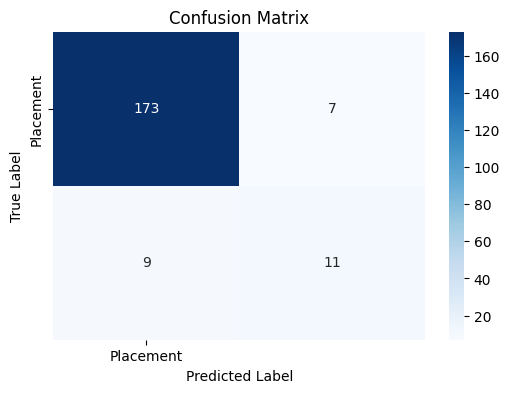

In [151]:
# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

unique_labels = np.unique("Placement").tolist()

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=unique_labels, yticklabels=unique_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

- Classification Metrics

    - **Accuracy** measures the overall proportion of correct predictions.

    - **Precision** measures how many predicted positive cases are actually positive.

    - **Recall** measures how many actual positive cases are correctly identified.
    
    - **F1-Score** balances Precision and Recall using their harmonic mean.

In [152]:
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.92
Precision: 0.6111111111111112
Recall   : 0.55
F1 Score : 0.5789473684210527


#### Generate Regression Dataset

In [153]:
n = 200

height = np.random.normal(168, 9, n)
weight = (0.52 * height - 28 + np.random.normal(0, 4, n))

df = pd.DataFrame({
    "Height": np.round(height, 1),
    "Weight": np.round(weight, 1)
})

df.head(20)

,Height,Weight
0,164.3,57.1
1,171.7,60.9
2,158.7,55.8
3,167.7,64.0
4,170.9,65.2
5,169.2,57.6
6,171.7,56.1
7,162.2,51.4
8,178.4,61.8
9,184.4,66.4


In [154]:
from sklearn.linear_model import LinearRegression

height, weight = height.reshape(-1, 1), weight.reshape(-1, 1)

model = LinearRegression()
model.fit(height, weight)

weight_pred = model.predict(height)
df["Predicted_Weight"] = weight_pred 
df.head(20)

,Height,Weight,Predicted_Weight
0,164.3,57.1,57.195761
1,171.7,60.9,60.947101
2,158.7,55.8,54.410418
3,167.7,64.0,58.910448
4,170.9,65.2,60.532286
5,169.2,57.6,59.670052
6,171.7,56.1,60.966224
7,162.2,51.4,56.162015
8,178.4,61.8,64.309160
9,184.4,66.4,67.348955


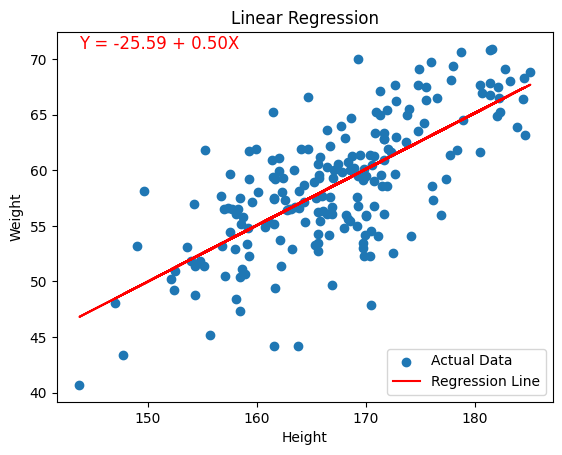

In [155]:
import matplotlib.pyplot as plt

# Draw the regression line
plt.scatter(df['Height'], df['Weight'], label='Actual Data')
plt.plot(df['Height'], df['Predicted_Weight'], color='red', label='Regression Line')
plt.text(x=df['Height'].min(), y=df['Weight'].max(), 
         s=f'Y = {model.intercept_[0]:.2f} + {model.coef_[0][0]:.2f}X', fontsize=12, color='red')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.title('Linear Regression')
plt.show()

- **Regression Metrics**

    - **Mean Absolute Error (MAE)** measures the average absolute difference between predicted and actual values.

    - **Mean Squared Error (MSE)** penalizes larger prediction errors by squaring the differences.

    - **Root Mean Squared Error (RMSE)** is the square root of MSE and is expressed in the same unit as the target variable.

    - **R² Score** indicates how well the model explains the variation in the target variable. A value closer to **1** indicates a better fit.

In [156]:
# Regression Metrics
from sklearn.metrics import (mean_absolute_error,
							mean_squared_error, r2_score)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.08
MSE : 0.08
RMSE: 0.282842712474619
R²  : 0.11111111111111127


#### Generate Unsupervised Dataset

In [157]:
# Define total samples (divisible by 3 for equal clusters)
n = 2700  
samples_per_cluster = n // 3

# 1. Height for 3 distinct groups (Short, Medium, Tall)
height = np.concatenate([
    np.random.normal(152, 4, samples_per_cluster),  # Cluster 0
    np.random.normal(168, 4, samples_per_cluster),  # Cluster 1
    np.random.normal(182, 5, samples_per_cluster)   # Cluster 2
])

# 2. Weight for 3 distinct groups (Light, Medium, Heavy)
weight = np.concatenate([
    np.random.normal(48, 4, samples_per_cluster),   # Cluster 0
    np.random.normal(62, 5, samples_per_cluster),   # Cluster 1
    np.random.normal(78, 6, samples_per_cluster)   # Cluster 2
])

# 3. Ground-truth labels updated for 3 clusters (0, 1, and 2)
true_label = np.concatenate([
    np.zeros(samples_per_cluster),                  # 0s
    np.ones(samples_per_cluster),                   # 1s
    np.ones(samples_per_cluster) * 2                # 2s
])

# Create the DataFrame
df = pd.DataFrame({
    "Height": np.round(height, 1),
    "Weight": np.round(weight, 1),
    "True Cluster": true_label.astype(int)
})

# Display group means to verify separation
df.groupby(by='True Cluster').agg('mean')

,Height,Weight
True Cluster,,
0,152.088667,48.005333
1,167.906667,62.156222
2,182.092556,77.736222


In [158]:
# Train K-Means
from sklearn.cluster import KMeans

X = df[["Height", "Weight"]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

pred_cluster = kmeans.fit_predict(X)

df["Predicted Cluster"] = pred_cluster

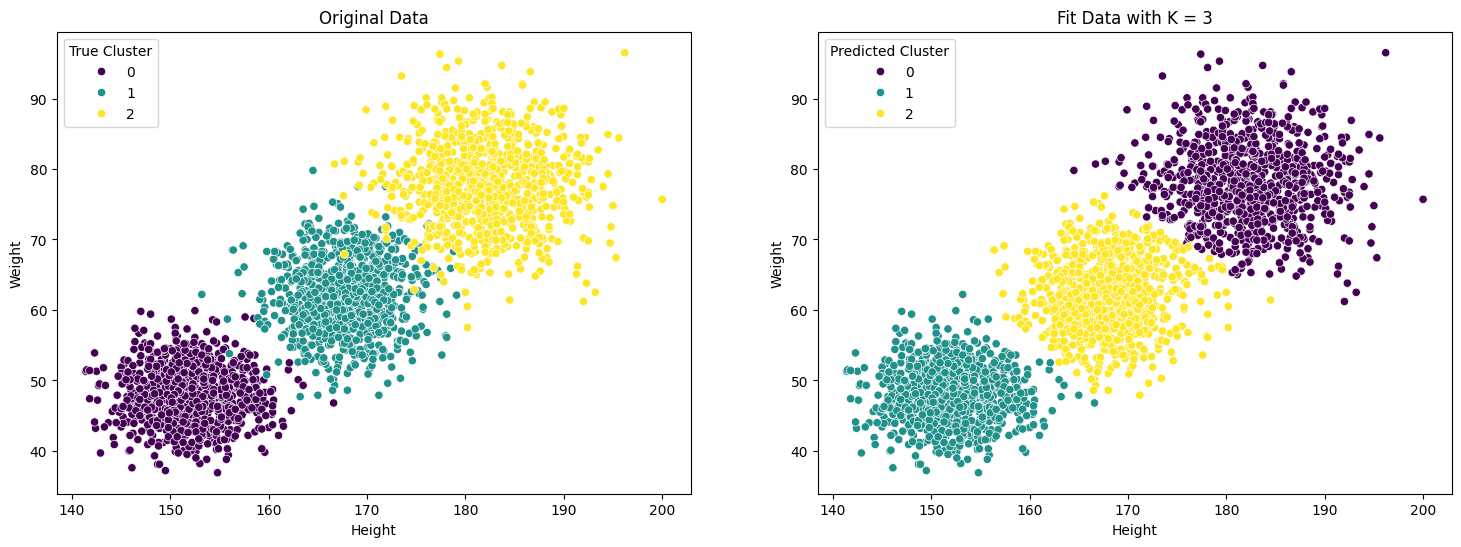

In [159]:
# Visualize the original data and fit data
fig, axs = plt.subplots(1, 2, figsize=(18, 6))
sns.scatterplot(data=df, x='Height', y='Weight', hue="True Cluster",
                palette='viridis', ax=axs[0])

axs[0].set_title('Original Data')
axs[0].set_xlabel('Height')
axs[0].set_ylabel('Weight')

sns.scatterplot(data=df, x='Height', y='Weight', hue="Predicted Cluster",
                palette='viridis', ax=axs[1])
axs[1].set_title('Fit Data with K = 3')
axs[1].set_xlabel('Height')
axs[1].set_ylabel('Weight')

plt.show()

- **Silhouette Score:** The **Silhouette Score** measures how well each sample belongs to its assigned cluster compared to other clusters. Its value ranges from **−1 to 1**.

    - **1** → Well-separated clusters
    
    - **0** → Overlapping clusters

    - **Negative** → Samples may belong to the wrong cluster

In [160]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, pred_cluster)
print("Silhouette Score:", score)

Silhouette Score: 0.5929172929557196


- Adjusted Rand Index (ARI): The **Adjusted Rand Index (ARI)** compares the predicted clusters with the actual labels. Its value ranges from **−1 to 1**.

    - **1** → Perfect clustering

    - **0** → Random clustering
    
    - **Negative** → Worse than random

In [161]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    df["True Cluster"],
    pred_cluster
)

print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.954100621456657
